# Financial Sentiment Classification: Three Architectures under One Dataset

Training TextCNN, BiLSTM, and FinBERT on the same financial text and measuring how much
their sentiment predictions diverge and what that divergence means for model risk.

**Data:** Financial PhraseBank (AllAgree), 2,259 sentences.
**Models:** TextCNN, BiLSTM, FinBERT, evaluated across 5 seeds.

In [ ]:
import torch
import sys, platform

print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"Platform: {platform.platform()}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Python: 3.12.13
PyTorch: 2.11.0+cu128
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
CUDA available: True
GPU: NVIDIA L4


In [ ]:
!pip install -q transformers datasets scikit-learn pandas numpy matplotlib seaborn tqdm

## 1. Environment

Records the runtime (Python, PyTorch, CUDA, GPU) so the run is reproducible. FinBERT
needs a GPU; the baselines don't.

In [ ]:
import os
import io
import json
import random
import zipfile
import requests
import warnings
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW, Adam
from torch.optim.lr_scheduler import LambdaLR

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, cohen_kappa_score
)

from transformers import AutoTokenizer, AutoModelForSequenceClassification

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_style("whitegrid")

## 2. Configuration
Every hyperparameter and run-control flag is housed here in one cell. From a validation
standpoint, below are the auditable settings.

In [ ]:
# ============================================================
# Run controls
# ============================================================
QUICK_RUN = False           # True = 1 seed, fewer epochs (dev mode)
SEEDS = [42, 123, 456, 789, 2024] if not QUICK_RUN else [42]

# ============================================================
# Data
# ============================================================
PHRASEBANK_URL = "https://huggingface.co/datasets/takala/financial_phrasebank/resolve/main/data/FinancialPhraseBank-v1.0.zip"
PHRASEBANK_FILE = "FinancialPhraseBank-v1.0/Sentences_AllAgree.txt"  # strictest agreement subset
LABEL_MAP = {"negative": 0, "neutral": 1, "positive": 2}
LABEL_NAMES = ["negative", "neutral", "positive"]

# 70/15/15 stratified
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

# ============================================================
# Tokenization (separate for baselines vs FinBERT)
# ============================================================
MAX_LEN = 64                # PhraseBank sentences are short; 64 covers >99%
BASELINE_VOCAB_SIZE = 15000  # for whitespace tokenizer
BASELINE_MIN_FREQ = 2

# ============================================================
# Training — baselines (CNN, BiLSTM)
# ============================================================
BASELINE_EMBED_DIM = 100      # matches GloVe 6B-100d
BASELINE_LR = 1e-3
BASELINE_BATCH_SIZE = 32
BASELINE_MAX_EPOCHS = 30
BASELINE_PATIENCE = 5         # early stopping on val macro-F1

# ============================================================
# Training — FinBERT
# ============================================================
FINBERT_MODEL_NAME = "ProsusAI/finbert"
FINBERT_LR = 2e-5
FINBERT_BATCH_SIZE = 16
FINBERT_MAX_EPOCHS = 8 if not QUICK_RUN else 4
FINBERT_PATIENCE = 2
FINBERT_WARMUP_FRAC = 0.1     # 10% warmup
FINBERT_WEIGHT_DECAY = 0.01

# ============================================================
# Calibration
# ============================================================
ECE_N_BINS = 15

print(f"QUICK_RUN={QUICK_RUN} | seeds={SEEDS}")
print(f"Device will be: {'cuda' if torch.cuda.is_available() else 'cpu'}")

QUICK_RUN=False | seeds=[42, 123, 456, 789, 2024]
Device will be: cuda


## 3. Data
Financial PhraseBank (Malo et al., 2014), using the AllAgree subset. The subset contains 2,259 unique English financial-news sentences labeled as negative, neutral, or positive. The class distribution is 61% neutral, 25% positive, and 14% negative. The AllAgree subset was selected to minimize label ambiguity so that observed disagreement can be attributed more confidently to differences in model architecture rather than annotation noise. The dataset is limited to short, English-language news sentences from a single source.

In [ ]:
def set_seed(seed: int):
    """Seed every source of randomness we care about."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

In [ ]:
def load_phrasebank() -> pd.DataFrame:
    """Download and parse Financial PhraseBank AllAgree subset."""
    response = requests.get(PHRASEBANK_URL, timeout=60)
    response.raise_for_status()
    zf = zipfile.ZipFile(io.BytesIO(response.content))

    with zf.open(PHRASEBANK_FILE) as f:
        # File is latin-1 encoded; lines are "sentence@label"
        lines = f.read().decode("latin-1").splitlines()

    records = []
    for line in lines:
        if "@" not in line:
            continue
        text, label_text = line.rsplit("@", 1)
        text = text.strip()
        label_text = label_text.strip().lower()
        if label_text not in LABEL_MAP:
            continue
        records.append({"text": text, "label_text": label_text, "label": LABEL_MAP[label_text]})

    df = pd.DataFrame(records).drop_duplicates(subset=["text"]).reset_index(drop=True)
    return df

df = load_phrasebank()
print(f"Loaded {len(df)} unique sentences")
print("\nLabel distribution:")
print(df["label_text"].value_counts())
print(f"\nClass balance: {(df['label_text'].value_counts(normalize=True) * 100).round(1).to_dict()}")
df.head(3)

Loaded 2259 unique sentences

Label distribution:
label_text
neutral     1386
positive     570
negative     303
Name: count, dtype: int64

Class balance: {'neutral': 61.4, 'positive': 25.2, 'negative': 13.4}


,text,label_text,label
0,"According to Gran , the company has no plans t...",neutral,1
1,"For the last quarter of 2010 , Componenta 's n...",positive,2
2,"In the third quarter of 2010 , net sales incre...",positive,2


## 4. Splits

Stratified 70/15/15 train/validation/test, re-drawn per seed so every run sees a
different partition. Stratifying on the label keeps the 61/25/14 class balance intact
across all three splits (confirmed below). The length check above sets `MAX_LEN = 64`:
median sentence is 21 words and only 0.04% exceed 64, so truncation loses almost nothing.

In [ ]:
# Sentence length distribution — sanity-check MAX_LEN
df["n_words"] = df["text"].str.split().str.len()
print(df["n_words"].describe().round(1))
print(f"\n% sentences with > {MAX_LEN} words: {(df['n_words'] > MAX_LEN).mean() * 100:.2f}%")

count    2259.0
mean       22.4
std        10.1
min         2.0
25%        15.0
50%        21.0
75%        28.0
max        81.0
Name: n_words, dtype: float64

% sentences with > 64 words: 0.04%


In [ ]:
def make_splits(df: pd.DataFrame, seed: int) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Stratified 70/15/15 split."""
    train_df, temp_df = train_test_split(
        df, test_size=(VAL_FRAC + TEST_FRAC),
        stratify=df["label"], random_state=seed
    )
    val_size_relative = VAL_FRAC / (VAL_FRAC + TEST_FRAC)
    val_df, test_df = train_test_split(
        temp_df, test_size=(1 - val_size_relative),
        stratify=temp_df["label"], random_state=seed
    )
    return (train_df.reset_index(drop=True),
            val_df.reset_index(drop=True),
            test_df.reset_index(drop=True))

# Demo split with seed 42
_train, _val, _test = make_splits(df, 42)
print(f"train={len(_train)} | val={len(_val)} | test={len(_test)}")
print(f"\nTrain label dist: {_train['label_text'].value_counts(normalize=True).round(3).to_dict()}")
print(f"Val label dist:   {_val['label_text'].value_counts(normalize=True).round(3).to_dict()}")
print(f"Test label dist:  {_test['label_text'].value_counts(normalize=True).round(3).to_dict()}")

train=1581 | val=339 | test=339

Train label dist: {'neutral': 0.614, 'positive': 0.252, 'negative': 0.134}
Val label dist:   {'neutral': 0.614, 'positive': 0.254, 'negative': 0.133}
Test label dist:  {'neutral': 0.614, 'positive': 0.251, 'negative': 0.136}


## 5. Tokenization

Baselines and FinBERT use **separate tokenizers**  the key fairness choice. FinBERT keeps
its native WordPiece; the baselines get a simple word-level tokenizer (lowercase, keep
alphanumerics, vocab built from the training split only, `<pad>`/`<unk>` reserved).

Sharing WordPiece would be unfair: its subword pieces (`##ing`, `##tion`) carry meaning
for FinBERT's pretrained embeddings but are noise to a randomly-initialized baseline. The
comparison would then measure tokenizer mismatch, not architecture.

In [ ]:
import re

_TOKEN_RE = re.compile(r"[a-z0-9]+(?:\.[0-9]+)?|\S")

def simple_tokenize(text: str) -> List[str]:
    """Lowercase, keep alphanumerics and decimals as tokens, treat punctuation as separate tokens."""
    return _TOKEN_RE.findall(text.lower())


class BaselineVocab:
    """Word-level vocabulary built from training corpus."""
    PAD = "<pad>"
    UNK = "<unk>"

    def __init__(self, max_size: int = BASELINE_VOCAB_SIZE, min_freq: int = BASELINE_MIN_FREQ):
        self.max_size = max_size
        self.min_freq = min_freq
        self.token2id: Dict[str, int] = {}
        self.id2token: List[str] = []

    def fit(self, texts: List[str]):
        counter = Counter()
        for t in texts:
            counter.update(simple_tokenize(t))

        self.id2token = [self.PAD, self.UNK]
        # most common tokens above min_freq, capped at max_size
        for tok, cnt in counter.most_common():
            if cnt < self.min_freq:
                break
            if len(self.id2token) >= self.max_size:
                break
            self.id2token.append(tok)
        self.token2id = {t: i for i, t in enumerate(self.id2token)}

    def encode(self, text: str, max_len: int) -> List[int]:
        ids = [self.token2id.get(t, 1) for t in simple_tokenize(text)][:max_len]  # 1 == <unk>
        ids += [0] * (max_len - len(ids))  # pad with 0
        return ids

    @property
    def size(self) -> int:
        return len(self.id2token)


# Smoke test
_vocab = BaselineVocab()
_vocab.fit(_train["text"].tolist())
print(f"Vocab size: {_vocab.size}")
print(f"Sample encode: {_vocab.encode(_train['text'].iloc[0], 20)}")

Vocab size: 2384
Sample encode: [2, 107, 17, 982, 6, 804, 12, 15, 245, 45, 51, 107, 1, 3, 0, 0, 0, 0, 0, 0]


## 6. GloVe embeddings for the baselines

The baseline embedding layers are initialized with GloVe 6B 100d vectors instead of random ones. With only ~1,580 training sentences, randomly initialized embeddings would likely underfit, as there is insufficient data to learn high-quality word representations from scratch. GloVe gives the CNN and BiLSTM a pretrained starting point, while allowing the embeddings to remain trainable during model fitting.
Tokens not found in GloVe fall back to small random initialization. The cell reports the OOV rate (out-of-vocabulary; the share of vocabulary tokens with no corresponding GloVe vector), which here is approximately 6%. The reported OOV rate helps quantify the extent to which the pretrained embeddings cover the financial vocabulary encountered in the dataset.

In [ ]:
GLOVE_DIR = "/content/glove" if os.path.exists("/content") else "./glove"
GLOVE_URL = "https://nlp.stanford.edu/data/glove.6B.zip"
GLOVE_FILE = "glove.6B.100d.txt"
GLOVE_PATH = os.path.join(GLOVE_DIR, GLOVE_FILE)


def download_glove():
    if os.path.exists(GLOVE_PATH):
        print(f"GloVe already cached at {GLOVE_PATH}")
        return
    os.makedirs(GLOVE_DIR, exist_ok=True)
    print("Downloading GloVe 6B (~830MB zipped, ~330MB for 100d)...")
    response = requests.get(GLOVE_URL, stream=True, timeout=300)
    response.raise_for_status()
    zip_path = os.path.join(GLOVE_DIR, "glove.6B.zip")
    with open(zip_path, "wb") as f:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            f.write(chunk)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extract(GLOVE_FILE, GLOVE_DIR)
    os.remove(zip_path)
    print(f"GloVe extracted to {GLOVE_PATH}")


def load_glove_matrix(vocab: BaselineVocab, embed_dim: int = BASELINE_EMBED_DIM) -> Tuple[np.ndarray, float]:
    """Build embedding matrix; return (matrix, OOV rate excluding pad/unk)."""
    download_glove()

    glove = {}
    with open(GLOVE_PATH, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip().split(" ")
            if len(parts) == embed_dim + 1:
                glove[parts[0]] = np.asarray(parts[1:], dtype=np.float32)

    # Random init scaled to GloVe's typical magnitude
    matrix = np.random.normal(0, 0.1, (vocab.size, embed_dim)).astype(np.float32)
    matrix[0] = 0.0  # <pad>

    hits, misses = 0, 0
    for i, tok in enumerate(vocab.id2token):
        if i < 2:  # skip pad, unk
            continue
        if tok in glove:
            matrix[i] = glove[tok]
            hits += 1
        else:
            misses += 1

    oov_rate = misses / max(1, hits + misses)
    print(f"GloVe coverage: {hits}/{hits + misses} ({(1 - oov_rate) * 100:.1f}%) | OOV rate: {oov_rate * 100:.1f}%")
    return matrix, oov_rate

## 7. Datasets

Two Dataset classes, one per tokenizer (Section 5). `BaselineDataset` encodes with the
word-level vocab; `FinBERTDataset` encodes with WordPiece. Both return the same
`{input_ids, attention_mask, label}` format, so a single training loop handles all three
models without special-casing.



In [ ]:
class BaselineDataset(Dataset):
    def __init__(self, texts, labels, vocab: BaselineVocab, max_len: int = MAX_LEN):
        self.texts = list(texts)
        self.labels = list(labels)
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = self.vocab.encode(self.texts[idx], self.max_len)
        ids_t = torch.tensor(ids, dtype=torch.long)
        mask_t = (ids_t != 0).long()
        label_t = torch.tensor(self.labels[idx], dtype=torch.long)
        return {"input_ids": ids_t, "attention_mask": mask_t, "label": label_t}


class FinBERTDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len: int = MAX_LEN):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label": torch.tensor(self.labels[idx], dtype=torch.long),
        }

## 8. Model definitions

The two baseline architectures. FinBERT is the third which loads pretrained from the
library during training, so it isn't defined here.

The three models are chosen to read text in fundamentally different ways, which is what
makes the disagreement analysis meaningful:

- **TextCNN** : convolutions over 3-, 4-, and 5-word windows, then max-pooling. Picks up
  *local phrases* ("net loss," "strong demand") regardless of where they sit in the sentence.
- **BiLSTM** : a bidirectional LSTM reading the sentence forward and backward. Captures
  *sequential structure* and longer-range dependencies between words.
- **FinBERT** : a transformer pretrained on financial text. Captures *full context* and
  brings prior exposure to financial vocabulary.

Both baselines share the same embedding layer (GloVe-initialized, Section 6) and dropout,
so the comparison isolates the architecture rather than confounding it with other
differences.

In [ ]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int = BASELINE_EMBED_DIM,
                 num_classes: int = 3, num_filters: int = 100,
                 kernel_sizes: Tuple[int, ...] = (3, 4, 5),
                 dropout: float = 0.4,
                 pretrained_embeddings: Optional[np.ndarray] = None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(torch.from_numpy(pretrained_embeddings))

        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, kernel_size=k, padding=k // 2)
            for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids)             # (B, T, E)
        x = x.permute(0, 2, 1)                    # (B, E, T)
        feats = [F.relu(conv(x)).max(dim=2).values for conv in self.convs]
        x = torch.cat(feats, dim=1)
        x = self.dropout(x)
        return self.fc(x)


class BiLSTM(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int = BASELINE_EMBED_DIM,
                 hidden_dim: int = 128, num_classes: int = 3,
                 dropout: float = 0.4,
                 pretrained_embeddings: Optional[np.ndarray] = None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(torch.from_numpy(pretrained_embeddings))

        self.lstm = nn.LSTM(
            input_size=embed_dim, hidden_size=hidden_dim,
            batch_first=True, bidirectional=True, num_layers=1,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids, attention_mask=None):
        # Use packed sequences for honest handling of variable lengths
        x = self.embedding(input_ids)
        if attention_mask is not None:
            lengths = attention_mask.sum(dim=1).clamp(min=1).cpu()
            packed = nn.utils.rnn.pack_padded_sequence(
                x, lengths, batch_first=True, enforce_sorted=False
            )
            _, (hidden, _) = self.lstm(packed)
        else:
            _, (hidden, _) = self.lstm(x)
        # hidden shape: (num_directions, B, H) -> concat last fwd + last bwd
        h = torch.cat([hidden[-2], hidden[-1]], dim=1)
        h = self.dropout(h)
        return self.fc(h)



## 9. Training utilities

One loop for all three models. Early stopping on **validation macro-F1** (not loss as
macro-F1 respects the class imbalance), restoring the best-validation checkpoint rather
than the last. Warmup+decay and gradient clipping for FinBERT are standard transformer
fine-tuning. `evaluate` also returns softmax probabilities, used later for calibration.

In [ ]:
def evaluate(model, loader, device, return_probs: bool = False):
    """Run model on a loader; return (preds, labels, [probs])."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"]

            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            if hasattr(logits, "logits"):  # HuggingFace returns ModelOutput
                logits = logits.logits

            probs = F.softmax(logits, dim=-1)
            preds = probs.argmax(dim=-1)

            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.numpy())
            all_probs.append(probs.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    all_probs = np.concatenate(all_probs)

    if return_probs:
        return all_preds, all_labels, all_probs
    return all_preds, all_labels


def linear_warmup_decay(optimizer, num_warmup_steps: int, num_total_steps: int):
    def lr_lambda(step):
        if step < num_warmup_steps:
            return step / max(1, num_warmup_steps)
        return max(0.0, (num_total_steps - step) / max(1, num_total_steps - num_warmup_steps))
    return LambdaLR(optimizer, lr_lambda)


def train_with_early_stopping(model, train_loader, val_loader, *,
                              optimizer, scheduler=None,
                              max_epochs: int, patience: int,
                              device, model_name: str = "model",
                              verbose: bool = True):
    """Generic train loop. Returns best model state + training history."""
    loss_fn = nn.CrossEntropyLoss()
    best_f1 = -1.0
    best_state = None
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.0
        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            optimizer.zero_grad()
            out = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = out.logits if hasattr(out, "logits") else out
            loss = loss_fn(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            if scheduler is not None:
                scheduler.step()
            running_loss += loss.item()

        train_loss = running_loss / max(1, len(train_loader))
        val_preds, val_labels = evaluate(model, val_loader, device)
        val_f1 = f1_score(val_labels, val_preds, average="macro")
        val_acc = accuracy_score(val_labels, val_preds)
        history.append({"epoch": epoch, "train_loss": train_loss, "val_f1": val_f1, "val_acc": val_acc})

        if verbose:
            print(f"  [{model_name}] epoch {epoch:02d} | train_loss={train_loss:.4f} | val_f1={val_f1:.4f} | val_acc={val_acc:.4f}")

        if val_f1 > best_f1 + 1e-4:
            best_f1 = val_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                if verbose:
                    print(f"  [{model_name}] early stop at epoch {epoch} (best val_f1={best_f1:.4f})")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history, best_f1

### 10  Single-seed run
run_one_seed runs the complete experiment once: split the data, build the baseline vocabulary and GloVe embeddings for TextCNN and BiLSTM, prepare FinBERT with its pretrained tokenizer and weights, train all three models, evaluate them on the same held-out test set, and store predictions and metrics in a SeedResult

In [ ]:
@dataclass
class SeedResult:
    seed: int
    test_df: pd.DataFrame
    preds: Dict[str, np.ndarray] = field(default_factory=dict)
    probs: Dict[str, np.ndarray] = field(default_factory=dict)
    metrics: Dict[str, Dict[str, float]] = field(default_factory=dict)
    histories: Dict[str, list] = field(default_factory=dict)
    glove_oov_rate: Optional[float] = None


def run_one_seed(seed: int, df: pd.DataFrame, device) -> SeedResult:
    print(f"\n{'='*60}\nSEED {seed}\n{'='*60}")
    set_seed(seed)
    train_df, val_df, test_df = make_splits(df, seed)

    # ---- Baseline pipeline ----
    vocab = BaselineVocab()
    vocab.fit(train_df["text"].tolist())
    glove_matrix, oov_rate = load_glove_matrix(vocab)

    base_train = BaselineDataset(train_df["text"], train_df["label"], vocab)
    base_val = BaselineDataset(val_df["text"], val_df["label"], vocab)
    base_test = BaselineDataset(test_df["text"], test_df["label"], vocab)

    base_train_loader = DataLoader(base_train, batch_size=BASELINE_BATCH_SIZE, shuffle=True)
    base_val_loader = DataLoader(base_val, batch_size=BASELINE_BATCH_SIZE)
    base_test_loader = DataLoader(base_test, batch_size=BASELINE_BATCH_SIZE)

    # ---- FinBERT pipeline ----
    finbert_tokenizer = AutoTokenizer.from_pretrained(FINBERT_MODEL_NAME)
    fin_train = FinBERTDataset(train_df["text"], train_df["label"], finbert_tokenizer)
    fin_val = FinBERTDataset(val_df["text"], val_df["label"], finbert_tokenizer)
    fin_test = FinBERTDataset(test_df["text"], test_df["label"], finbert_tokenizer)

    fin_train_loader = DataLoader(fin_train, batch_size=FINBERT_BATCH_SIZE, shuffle=True)
    fin_val_loader = DataLoader(fin_val, batch_size=FINBERT_BATCH_SIZE)
    fin_test_loader = DataLoader(fin_test, batch_size=FINBERT_BATCH_SIZE)

    result = SeedResult(seed=seed, test_df=test_df, glove_oov_rate=oov_rate)

    # ---- Train TextCNN ----
    print("\n[TextCNN] training...")
    cnn = TextCNN(vocab.size, pretrained_embeddings=glove_matrix).to(device)
    cnn_opt = Adam(cnn.parameters(), lr=BASELINE_LR)
    cnn, cnn_hist, _ = train_with_early_stopping(
        cnn, base_train_loader, base_val_loader,
        optimizer=cnn_opt, max_epochs=BASELINE_MAX_EPOCHS,
        patience=BASELINE_PATIENCE, device=device, model_name="TextCNN",
    )
    cnn_preds, cnn_labels, cnn_probs = evaluate(cnn, base_test_loader, device, return_probs=True)
    result.preds["TextCNN"] = cnn_preds
    result.probs["TextCNN"] = cnn_probs
    result.histories["TextCNN"] = cnn_hist

    # ---- Train BiLSTM ----
    print("\n[BiLSTM] training...")
    lstm = BiLSTM(vocab.size, pretrained_embeddings=glove_matrix).to(device)
    lstm_opt = Adam(lstm.parameters(), lr=BASELINE_LR)
    lstm, lstm_hist, _ = train_with_early_stopping(
        lstm, base_train_loader, base_val_loader,
        optimizer=lstm_opt, max_epochs=BASELINE_MAX_EPOCHS,
        patience=BASELINE_PATIENCE, device=device, model_name="BiLSTM",
    )
    lstm_preds, lstm_labels, lstm_probs = evaluate(lstm, base_test_loader, device, return_probs=True)
    result.preds["BiLSTM"] = lstm_preds
    result.probs["BiLSTM"] = lstm_probs
    result.histories["BiLSTM"] = lstm_hist

    # ---- Train FinBERT ----
    print("\n[FinBERT] fine-tuning...")
    finbert = AutoModelForSequenceClassification.from_pretrained(
        FINBERT_MODEL_NAME, num_labels=3, ignore_mismatched_sizes=True
    ).to(device)
    no_decay = ["bias", "LayerNorm.weight"]
    grouped = [
        {"params": [p for n, p in finbert.named_parameters() if not any(nd in n for nd in no_decay)],
         "weight_decay": FINBERT_WEIGHT_DECAY},
        {"params": [p for n, p in finbert.named_parameters() if any(nd in n for nd in no_decay)],
         "weight_decay": 0.0},
    ]
    fin_opt = AdamW(grouped, lr=FINBERT_LR)
    total_steps = len(fin_train_loader) * FINBERT_MAX_EPOCHS
    fin_sched = linear_warmup_decay(
        fin_opt,
        num_warmup_steps=int(FINBERT_WARMUP_FRAC * total_steps),
        num_total_steps=total_steps,
    )
    finbert, fin_hist, _ = train_with_early_stopping(
        finbert, fin_train_loader, fin_val_loader,
        optimizer=fin_opt, scheduler=fin_sched,
        max_epochs=FINBERT_MAX_EPOCHS, patience=FINBERT_PATIENCE,
        device=device, model_name="FinBERT",
    )
    fin_preds, fin_labels, fin_probs = evaluate(finbert, fin_test_loader, device, return_probs=True)
    result.preds["FinBERT"] = fin_preds
    result.probs["FinBERT"] = fin_probs
    result.histories["FinBERT"] = fin_hist

    # Sanity: all three models evaluated on same test set in same order
    assert np.array_equal(cnn_labels, lstm_labels), "Test label order mismatch CNN/BiLSTM"
    assert np.array_equal(cnn_labels, fin_labels), "Test label order mismatch CNN/FinBERT"
    result.test_df = test_df.reset_index(drop=True)
    result.test_df["true"] = cnn_labels  # canonical truth column

    # Per-model metrics
    for name, preds in result.preds.items():
        result.metrics[name] = {
            "accuracy": accuracy_score(cnn_labels, preds),
            "macro_f1": f1_score(cnn_labels, preds, average="macro"),
            "weighted_f1": f1_score(cnn_labels, preds, average="weighted"),
        }
        print(f"  {name}: acc={result.metrics[name]['accuracy']:.4f} | macro-F1={result.metrics[name]['macro_f1']:.4f}")

    # Free memory
    del cnn, lstm, finbert
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result

## 11. Multi-seed run

Run the full pipeline across all 5 seeds and collect the results. This is what puts error
bars on every number that follows.

A single seed can mislead: one run might show 11% disagreement, another 16%, just from a
different random split and weight init. Reporting one number invites the obvious question: 
*would it hold on a different run?* Five seeds answer that up front. Every metric from here
on is reported as **mean ± std across seeds**, so the spread is part of the claim rather
than something a reviewer has to ask about.

Runtime is a few minutes per seed on GPU; the FinBERT download happens once and caches.

In [ ]:
all_results: List[SeedResult] = []
for seed in SEEDS:
    res = run_one_seed(seed, df, device)
    all_results.append(res)

print(f"\n\nCompleted {len(all_results)} seeds.")


SEED 42
GloVe extracted to /content/glove/glove.6B.100d.txt
GloVe coverage: 2241/2382 (94.1%) | OOV rate: 5.9%


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

  [FinBERT] epoch 01 | train_loss=1.3726 | val_f1=0.9274 | val_acc=0.9528
  [FinBERT] epoch 02 | train_loss=0.1247 | val_f1=0.9587 | val_acc=0.9646
  [FinBERT] epoch 03 | train_loss=0.0430 | val_f1=0.9662 | val_acc=0.9735
  [FinBERT] epoch 04 | train_loss=0.0193 | val_f1=0.9660 | val_acc=0.9764
  [FinBERT] epoch 05 | train_loss=0.0137 | val_f1=0.9686 | val_acc=0.9764
  [FinBERT] epoch 06 | train_loss=0.0033 | val_f1=0.9687 | val_acc=0.9764
  [FinBERT] epoch 07 | train_loss=0.0019 | val_f1=0.9661 | val_acc=0.9735
  [FinBERT] epoch 08 | train_loss=0.0014 | val_f1=0.9661 | val_acc=0.9735
  [FinBERT] early stop at epoch 8 (best val_f1=0.9687)
  TextCNN: acc=0.8909 | macro-F1=0.8442
  BiLSTM: acc=0.8260 | macro-F1=0.7658
  FinBERT: acc=0.9558 | macro-F1=0.9333

SEED 789
GloVe already cached at /content/glove/glove.6B.100d.txt
GloVe coverage: 2200/2344 (93.9%) | OOV rate: 6.1%

[TextCNN] training...
  [TextCNN] epoch 01 | train_loss=0.7495 | val_f1=0.6288 | val_acc=0.7729
  [TextCNN] epoch 0

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  [FinBERT] epoch 01 | train_loss=1.4379 | val_f1=0.8530 | val_acc=0.9204
  [FinBERT] epoch 02 | train_loss=0.1509 | val_f1=0.9204 | val_acc=0.9528
  [FinBERT] epoch 03 | train_loss=0.0503 | val_f1=0.9332 | val_acc=0.9587
  [FinBERT] epoch 04 | train_loss=0.0198 | val_f1=0.9317 | val_acc=0.9587
  [FinBERT] epoch 05 | train_loss=0.0083 | val_f1=0.9502 | val_acc=0.9646
  [FinBERT] epoch 06 | train_loss=0.0029 | val_f1=0.9624 | val_acc=0.9735
  [FinBERT] epoch 07 | train_loss=0.0017 | val_f1=0.9597 | val_acc=0.9705
  [FinBERT] epoch 08 | train_loss=0.0014 | val_f1=0.9624 | val_acc=0.9735
  [FinBERT] early stop at epoch 8 (best val_f1=0.9624)
  TextCNN: acc=0.9086 | macro-F1=0.8793
  BiLSTM: acc=0.9056 | macro-F1=0.8711
  FinBERT: acc=0.9823 | macro-F1=0.9754

SEED 2024
GloVe already cached at /content/glove/glove.6B.100d.txt
GloVe coverage: 2251/2389 (94.2%) | OOV rate: 5.8%

[TextCNN] training...
  [TextCNN] epoch 01 | train_loss=0.7532 | val_f1=0.5102 | val_acc=0.7640
  [TextCNN] epoch 

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  [FinBERT] epoch 01 | train_loss=1.4154 | val_f1=0.7822 | val_acc=0.8997
  [FinBERT] epoch 02 | train_loss=0.1298 | val_f1=0.9601 | val_acc=0.9735
  [FinBERT] epoch 03 | train_loss=0.0467 | val_f1=0.9506 | val_acc=0.9617
  [FinBERT] epoch 04 | train_loss=0.0250 | val_f1=0.9591 | val_acc=0.9735
  [FinBERT] early stop at epoch 4 (best val_f1=0.9601)
  TextCNN: acc=0.8938 | macro-F1=0.8343
  BiLSTM: acc=0.8820 | macro-F1=0.8316
  FinBERT: acc=0.9528 | macro-F1=0.9234


Completed 5 seeds.


## 12. Performance: Table 1

The headline table: accuracy, macro-F1, and weighted-F1 for each model, as mean ± std
across the 5 seeds: every number carries its variance, the form a model risk committee
expects.

**FinBERT wins clearly**  macro-F1 0.96 vs. 0.86 (TextCNN) and 0.83 (BiLSTM), a 10+ point
gap, and with the tightest spread. Among the baselines, TextCNN edges out BiLSTM. Macro-F1
sits below accuracy for every model and that gap is the minority classes being harder than
the neutral majority, exactly what the 61/25/14 imbalance predicts.

In [ ]:
def summarize_metric(values: List[float]) -> str:
    arr = np.asarray(values)
    if len(arr) == 1:
        return f"{arr[0]:.4f} (n=1)"
    return f"{arr.mean():.4f} ± {arr.std(ddof=1):.4f}"


perf_rows = []
for model_name in ["TextCNN", "BiLSTM", "FinBERT"]:
    accs = [r.metrics[model_name]["accuracy"] for r in all_results]
    f1s = [r.metrics[model_name]["macro_f1"] for r in all_results]
    wf1s = [r.metrics[model_name]["weighted_f1"] for r in all_results]
    perf_rows.append({
        "Model": model_name,
        "Accuracy": summarize_metric(accs),
        "Macro-F1": summarize_metric(f1s),
        "Weighted-F1": summarize_metric(wf1s),
    })

perf_df = pd.DataFrame(perf_rows)
print("=" * 70)
print("TABLE 1 — Test-set performance across {} seeds".format(len(SEEDS)))
print("=" * 70)
print(perf_df.to_string(index=False))

TABLE 1 — Test-set performance across 5 seeds
  Model        Accuracy        Macro-F1     Weighted-F1
TextCNN 0.9038 ± 0.0142 0.8636 ± 0.0245 0.9014 ± 0.0154
 BiLSTM 0.8885 ± 0.0388 0.8456 ± 0.0504 0.8879 ± 0.0373
FinBERT 0.9693 ± 0.0148 0.9531 ± 0.0242 0.9691 ± 0.0150


### FinBERT per-class F1

Breaking FinBERT down by label. It nails **neutral** (F1 0.99, the majority class) and
holds **positive** at 0.96, but **negative** is both the weakest and by far the most
variable class: 0.93 ± 0.04, with seed 456 dropping to 0.87.

Negative is the smallest class (14% of the data) and the one FinBERT is least stable on
across seeds. For a risk application that's the uncomfortable finding: negative sentiment
is often the consequential signal, and it's the one the best model holds least firmly.

In [ ]:
# Per-class F1 across seeds (FinBERT only, for inspection)
per_class_rows = []
for r in all_results:
    finbert_preds = r.preds["FinBERT"]
    true = r.test_df["true"].values
    per_class_f1 = f1_score(true, finbert_preds, average=None)
    per_class_rows.append({"seed": r.seed, **dict(zip(LABEL_NAMES, per_class_f1))})

per_class_df = pd.DataFrame(per_class_rows)
print("\nFinBERT per-class F1 across seeds:")
print(per_class_df.to_string(index=False))
print("\nMean ± std per class:")
for cls in LABEL_NAMES:
    vals = per_class_df[cls].values
    print(f"  {cls:<10s}: {summarize_metric(vals.tolist())}")


FinBERT per-class F1 across seeds:
 seed  negative  neutral  positive
   42  0.954545 0.992806  0.982659
  123  0.921348 0.983133  0.965517
  456  0.876404 0.976077  0.947368
  789  0.955556 0.987952  0.982659
 2024  0.867470 0.985507  0.917127

Mean ± std per class:
  negative  : 0.9151 ± 0.0418
  neutral   : 0.9851 ± 0.0062
  positive  : 0.9591 ± 0.0276



## 13. Model agreement: Tables 2 & 3

The central finding: three models on identical data disagree on **13.5% ± 2.8%** of test
sentences (Table 2) which is ~1 in 7. Pairwise (Table 3), the baselines agree most with each other
(κ 0.86) while **BiLSTM↔FinBERT agree least** (κ 0.78), the most accurate model is the one
the others diverge from most. Picking the winner doesn't erase the disagreement; it makes
the architecture choice a documented model-development decision.

In [ ]:
def three_way_disagreement(preds_dict: Dict[str, np.ndarray]) -> float:
    a, b, c = preds_dict["TextCNN"], preds_dict["BiLSTM"], preds_dict["FinBERT"]
    return float(1 - np.mean((a == b) & (b == c)))


# Three-way disagreement
disagreements = [three_way_disagreement(r.preds) for r in all_results]
print("=" * 70)
print("TABLE 2 — Three-way disagreement rate (TextCNN / BiLSTM / FinBERT)")
print("=" * 70)
print(f"  Across {len(SEEDS)} seeds: {summarize_metric(disagreements)}")
print(f"  Range: [{min(disagreements):.4f}, {max(disagreements):.4f}]")

TABLE 2 — Three-way disagreement rate (TextCNN / BiLSTM / FinBERT)
  Across 5 seeds: 0.1251 ± 0.0267
  Range: [0.0973, 0.1681]


In [ ]:
# Pairwise: disagreement rate + Cohen's kappa
PAIRS = [("TextCNN", "BiLSTM"), ("TextCNN", "FinBERT"), ("BiLSTM", "FinBERT")]

pairwise_data = defaultdict(lambda: {"disagree": [], "kappa": []})
for r in all_results:
    for a, b in PAIRS:
        pa, pb = r.preds[a], r.preds[b]
        pairwise_data[(a, b)]["disagree"].append(float(np.mean(pa != pb)))
        pairwise_data[(a, b)]["kappa"].append(float(cohen_kappa_score(pa, pb)))

pairwise_rows = []
for (a, b), d in pairwise_data.items():
    pairwise_rows.append({
        "Pair": f"{a} vs {b}",
        "Disagreement": summarize_metric(d["disagree"]),
        "Cohen's κ": summarize_metric(d["kappa"]),
    })
pairwise_df = pd.DataFrame(pairwise_rows)
print("=" * 70)
print("TABLE 3 — Pairwise model agreement")
print("=" * 70)
print(pairwise_df.to_string(index=False))

TABLE 3 — Pairwise model agreement
              Pair    Disagreement       Cohen's κ
 TextCNN vs BiLSTM 0.0678 ± 0.0273 0.8703 ± 0.0487
TextCNN vs FinBERT 0.0873 ± 0.0092 0.8339 ± 0.0187
 BiLSTM vs FinBERT 0.1038 ± 0.0278 0.8067 ± 0.0477


### Visualizing the agreement structure

The same pairwise numbers as bar charts: disagreement rate (left) and Cohen's κ (right),
mean ± std. The κ reference lines mark the *substantial* (0.6) and *strong* (0.8)
thresholds. All three pairs clear "strong," but the ordering is the point: the
FinBERT-involving pairs sit lowest, with BiLSTM↔FinBERT the weakest agreement.

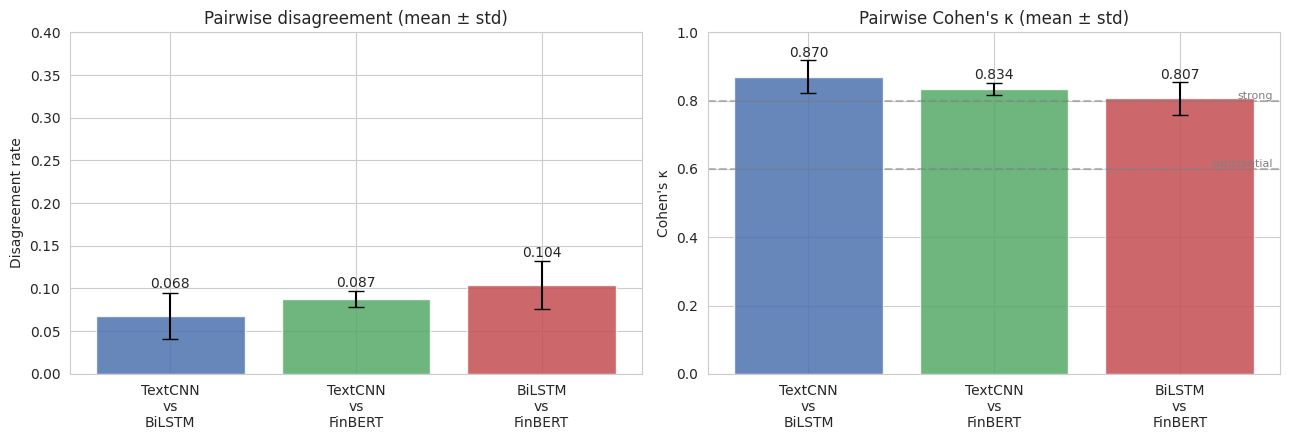

In [ ]:
# Visualize disagreement structure
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: bar chart of pairwise disagreement
labels = [f"{a}\nvs\n{b}" for a, b in PAIRS]
means = [np.mean(pairwise_data[(a, b)]["disagree"]) for a, b in PAIRS]
stds = [np.std(pairwise_data[(a, b)]["disagree"], ddof=1) if len(SEEDS) > 1 else 0 for a, b in PAIRS]
axes[0].bar(labels, means, yerr=stds, capsize=6, color=["#4C72B0", "#55A868", "#C44E52"], alpha=0.85)
axes[0].set_ylabel("Disagreement rate")
axes[0].set_title("Pairwise disagreement (mean ± std)")
axes[0].set_ylim(0, max(0.4, max(means) * 1.4))
for i, (m, s) in enumerate(zip(means, stds)):
    axes[0].text(i, m + s + 0.005, f"{m:.3f}", ha="center", fontsize=10)

# Right: bar chart of Cohen's kappa
means_k = [np.mean(pairwise_data[(a, b)]["kappa"]) for a, b in PAIRS]
stds_k = [np.std(pairwise_data[(a, b)]["kappa"], ddof=1) if len(SEEDS) > 1 else 0 for a, b in PAIRS]
axes[1].bar(labels, means_k, yerr=stds_k, capsize=6, color=["#4C72B0", "#55A868", "#C44E52"], alpha=0.85)
axes[1].set_ylabel("Cohen's κ")
axes[1].set_title("Pairwise Cohen's κ (mean ± std)")
axes[1].set_ylim(0, 1)
axes[1].axhline(0.6, color="gray", linestyle="--", alpha=0.5)
axes[1].axhline(0.8, color="gray", linestyle="--", alpha=0.5)
axes[1].text(2.5, 0.6, "substantial", fontsize=8, color="gray", va="bottom", ha="right")
axes[1].text(2.5, 0.8, "strong", fontsize=8, color="gray", va="bottom", ha="right")
for i, (m, s) in enumerate(zip(means_k, stds_k)):
    axes[1].text(i, m + s + 0.01, f"{m:.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

### 14. Calibration: Table 4
Accuracy is not the whole story. A model that is correct 70% of the time but routinely reports 95% confidence is miscalibrated, and that matters because downstream processes often consume probabilities rather than labels.
Expected Calibration Error (ECE) measures the gap between confidence and reality. Predictions are grouped by confidence level, and within each group average confidence is compared with observed accuracy. Lower values indicate better calibration: a well-calibrated model's confidence estimates closely match how often it is actually correct.
FinBERT is the best-calibrated model (ECE = 0.024), ahead of TextCNN (0.055) and BiLSTM (0.082). FinBERT is therefore not only the most accurate model but also the most reliable in the confidence it attaches to its predictions. BiLSTM performs worst on both dimensions and exhibits the greatest variability across runs.
For a governance audience, the implication is straightforward: confidence estimates cannot be assumed to have the same meaning across architectures. A confidence threshold validated for one model should not automatically be transferred to another. Calibration is a model-specific property, and differences in calibration represent a dimension of model performance that accuracy and macro-F1 alone do not capture

In [ ]:
def expected_calibration_error(probs: np.ndarray, labels: np.ndarray, n_bins: int = ECE_N_BINS) -> Tuple[float, dict]:
    """Top-label ECE. Returns (ece, per-bin diagnostics)."""
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies = (predictions == labels).astype(float)

    bins = np.linspace(0, 1, n_bins + 1)
    bin_lowers, bin_uppers = bins[:-1], bins[1:]

    ece = 0.0
    bin_data = {"bin_lower": [], "bin_upper": [], "count": [],
                "avg_confidence": [], "avg_accuracy": []}
    n = len(labels)
    for lo, hi in zip(bin_lowers, bin_uppers):
        in_bin = (confidences > lo) & (confidences <= hi)
        if lo == 0:
            in_bin = (confidences >= lo) & (confidences <= hi)
        count = in_bin.sum()
        if count > 0:
            avg_conf = confidences[in_bin].mean()
            avg_acc = accuracies[in_bin].mean()
            ece += (count / n) * abs(avg_conf - avg_acc)
            bin_data["bin_lower"].append(lo)
            bin_data["bin_upper"].append(hi)
            bin_data["count"].append(int(count))
            bin_data["avg_confidence"].append(float(avg_conf))
            bin_data["avg_accuracy"].append(float(avg_acc))
    return float(ece), bin_data


calibration_rows = []
all_bin_data = {m: [] for m in ["TextCNN", "BiLSTM", "FinBERT"]}
for r in all_results:
    true = r.test_df["true"].values
    for m in ["TextCNN", "BiLSTM", "FinBERT"]:
        ece, bin_data = expected_calibration_error(r.probs[m], true)
        calibration_rows.append({"seed": r.seed, "model": m, "ECE": ece})
        all_bin_data[m].append(bin_data)

cal_df = pd.DataFrame(calibration_rows)
print("=" * 70)
print("TABLE 4 — Expected Calibration Error (lower = better)")
print("=" * 70)
for m in ["TextCNN", "BiLSTM", "FinBERT"]:
    vals = cal_df[cal_df["model"] == m]["ECE"].tolist()
    print(f"  {m:<10s}: {summarize_metric(vals)}")

TABLE 4 — Expected Calibration Error (lower = better)
  TextCNN   : 0.0610 ± 0.0123
  BiLSTM    : 0.0898 ± 0.0287
  FinBERT   : 0.0222 ± 0.0089


### Reliability diagrams

ECE as a picture, one model per panel (seed 42 shown for clarity). The dashed diagonal is
perfect calibration confidence equals accuracy. The black line is where each model
actually sits: **above** the diagonal means underconfident, **below** means overconfident.

FinBERT tracks the diagonal closely; the baselines run below it, especially in the
high-confidence bins where they're often *more* sure than they should be. The note that 95%
confidence isn't matched by 95% accuracy is exactly what the lower line shows. Overconfident
high-probability predictions are the dangerous kind in a thresholding pipeline, since
that's the region where a downstream system is most likely to act on the score.

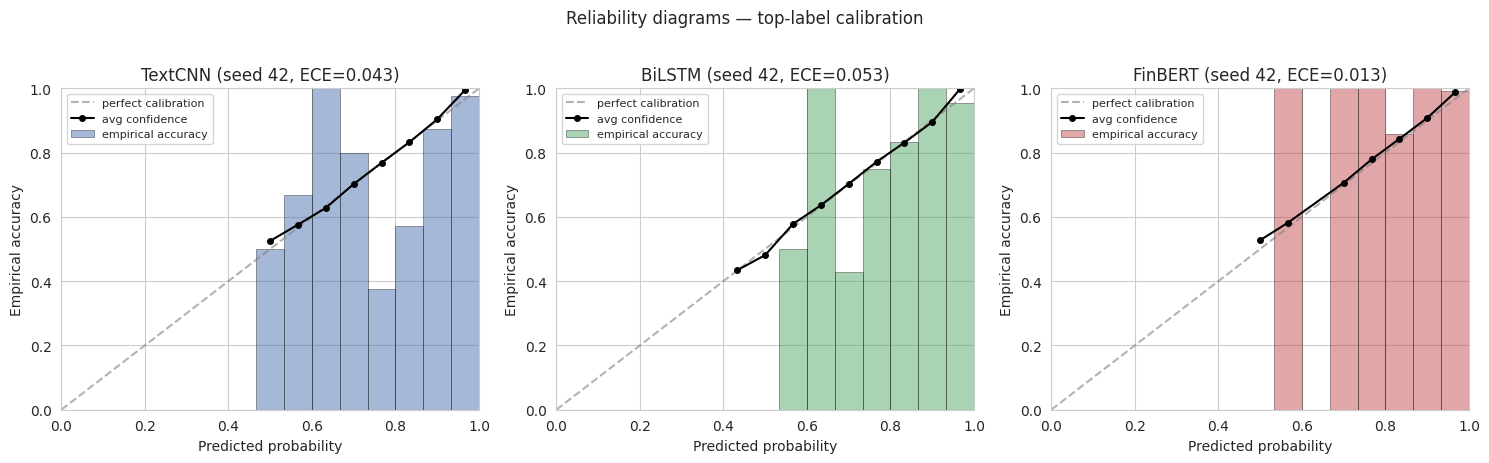

In [ ]:
# Reliability diagrams (using seed-0 result for clarity; all seeds available in all_bin_data)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, m, color in zip(axes, ["TextCNN", "BiLSTM", "FinBERT"], ["#4C72B0", "#55A868", "#C44E52"]):
    bd = all_bin_data[m][0]  # first seed
    centers = [(lo + hi) / 2 for lo, hi in zip(bd["bin_lower"], bd["bin_upper"])]
    ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.6, label="perfect calibration")
    ax.bar(centers, bd["avg_accuracy"], width=1.0 / ECE_N_BINS, alpha=0.5,
           color=color, edgecolor="black", linewidth=0.5, label="empirical accuracy")
    ax.plot(centers, bd["avg_confidence"], "o-", color="black", markersize=4, label="avg confidence")
    seed_ece = cal_df[(cal_df["model"] == m) & (cal_df["seed"] == all_results[0].seed)]["ECE"].values[0]
    ax.set_title(f"{m} (seed {all_results[0].seed}, ECE={seed_ece:.3f})")
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Empirical accuracy")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc="upper left", fontsize=8)
plt.suptitle("Reliability diagrams — top-label calibration", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## 15. Segment-level error analysis Table 5

Aggregate metrics hide the cases that matter most. Here the test set is split by linguistic
feature, and per-model macro-F1 and three-way disagreement are recomputed on each segment.
Four flags: **negation** (not, no, never...), **hedging** (may, might, expects,
anticipates...), **numerics** (digits or %), and **sentence length** (above/below median).

The original hypothesis was that models would disagree most on hedged/forward-looking *and*
negated language. The results partly confirm and partly overturn it:

- **Hedging is the disagreement hotspot** : 20.8% three-way disagreement vs. 12.7% on
  non-hedged text. This is the headline segment result: the models diverge most on
  forward-looking, conditional language — *expects*, *anticipates*, *likely* which is
  exactly the text that drives forward-looking risk judgments.
- **Negation went the other way**: only 2.9% disagreement, *lower* than baseline. But
  n≈13 per seed with ±0.28 F1 swings, so the sample is too thin to read much into; flag it,
  don't lean on it.
- **Numeric content reveals baseline dependence on quantitative cues**:  on non-numeric text the baselines collapse (F1 ~0.67)
  while FinBERT holds (0.90). The baselines lean heavily on numeric cues; FinBERT reads the
  language.
  
- **Longer sentences disagree more** (17.0% vs. 10.4% on short):  more room for the three
  architectures to diverge.

The governance read: disagreement isn't uniform noise. It concentrates on hedged,
forward-looking, longer sentences the linguistically hard, decision-relevant inputs. An
aggregate accuracy number would have hidden that entirely, which is why input
stratification belongs in a conceptual-soundness review, not just a headline metric.

In [ ]:
NEGATION_TOKENS = {"not", "no", "never", "n't", "without", "nor", "neither", "hardly", "barely"}
HEDGING_TOKENS = {
    "may", "might", "could", "expects", "expect", "expected",
    "anticipates", "anticipate", "anticipated",
    "plans", "plan", "planned", "intends", "intend", "intended",
    "estimates", "estimate", "estimated", "projected", "projects", "project",
    "possibly", "likely", "seems", "seem", "appears", "appear",
    "forecasts", "forecast",
}
NUMERIC_RE = re.compile(r"\d|%")


def segment_flags(text: str) -> Dict[str, bool]:
    toks = set(simple_tokenize(text))
    return {
        "has_negation": bool(toks & NEGATION_TOKENS),
        "has_hedging": bool(toks & HEDGING_TOKENS),
        "has_numeric": bool(NUMERIC_RE.search(text)),
    }


def aggregate_segment(all_results: List[SeedResult], mask_fn) -> Dict[str, str]:
    """Compute per-model macro-F1 and three-way disagreement on a segment, across seeds."""
    per_seed_metrics = {m: [] for m in ["TextCNN", "BiLSTM", "FinBERT"]}
    per_seed_disagree = []
    counts = []
    for r in all_results:
        mask = mask_fn(r.test_df)
        if mask.sum() == 0:
            continue
        counts.append(int(mask.sum()))
        true = r.test_df.loc[mask, "true"].values
        seg_preds = {}
        for m in ["TextCNN", "BiLSTM", "FinBERT"]:
            p = r.preds[m][mask.values]
            per_seed_metrics[m].append(f1_score(true, p, average="macro"))
            seg_preds[m] = p
        per_seed_disagree.append(three_way_disagreement(seg_preds))

    if not counts:
        return None

    out = {"avg_segment_size": int(np.mean(counts))}
    for m in ["TextCNN", "BiLSTM", "FinBERT"]:
        out[f"{m} F1"] = summarize_metric(per_seed_metrics[m])
    out["3-way disagree"] = summarize_metric(per_seed_disagree)
    return out


# Tag each seed's test_df with segment flags
for r in all_results:
    flags_df = r.test_df["text"].apply(lambda t: pd.Series(segment_flags(t)))
    for c in flags_df.columns:
        r.test_df[c] = flags_df[c]
    r.test_df["n_words"] = r.test_df["text"].str.split().str.len()
    median_len = r.test_df["n_words"].median()
    r.test_df["is_long"] = r.test_df["n_words"] > median_len

segment_definitions = [
    ("ALL",                  lambda d: pd.Series([True] * len(d), index=d.index)),
    ("Has negation",         lambda d: d["has_negation"]),
    ("No negation",          lambda d: ~d["has_negation"]),
    ("Has hedging",          lambda d: d["has_hedging"]),
    ("No hedging",           lambda d: ~d["has_hedging"]),
    ("Has numeric",          lambda d: d["has_numeric"]),
    ("No numeric",           lambda d: ~d["has_numeric"]),
    ("Long sentences",       lambda d: d["is_long"]),
    ("Short sentences",      lambda d: ~d["is_long"]),
]

segment_rows = []
for name, fn in segment_definitions:
    agg = aggregate_segment(all_results, fn)
    if agg is None:
        continue
    segment_rows.append({"Segment": name, "n (avg)": agg["avg_segment_size"], **{k: v for k, v in agg.items() if k != "avg_segment_size"}})

segment_df = pd.DataFrame(segment_rows)
print("=" * 100)
print("TABLE 5 — Per-segment macro-F1 and three-way disagreement")
print("=" * 100)
print(segment_df.to_string(index=False))

TABLE 5 — Per-segment macro-F1 and three-way disagreement
        Segment  n (avg)      TextCNN F1       BiLSTM F1      FinBERT F1  3-way disagree
            ALL      339 0.8636 ± 0.0245 0.8456 ± 0.0504 0.9531 ± 0.0242 0.1251 ± 0.0267
   Has negation       13 0.6977 ± 0.2769 0.6839 ± 0.2886 0.7677 ± 0.2665 0.0542 ± 0.0543
    No negation      325 0.8649 ± 0.0245 0.8472 ± 0.0507 0.9548 ± 0.0228 0.1279 ± 0.0283
    Has hedging       31 0.8081 ± 0.0988 0.7438 ± 0.0909 0.9455 ± 0.0518 0.2077 ± 0.0752
     No hedging      308 0.8703 ± 0.0305 0.8559 ± 0.0537 0.9548 ± 0.0280 0.1162 ± 0.0306
    Has numeric      209 0.8940 ± 0.0186 0.8709 ± 0.0469 0.9733 ± 0.0115 0.1306 ± 0.0393
     No numeric      130 0.6656 ± 0.0852 0.6871 ± 0.1341 0.8302 ± 0.0884 0.1162 ± 0.0182
 Long sentences      161 0.8522 ± 0.0111 0.8320 ± 0.0404 0.9678 ± 0.0114 0.1575 ± 0.0246
Short sentences      178 0.8737 ± 0.0405 0.8600 ± 0.0626 0.9346 ± 0.0414 0.0956 ± 0.0289



### Where the models disagree

Three-way disagreement by segment; the dashed line is the overall mean (0.135). **Hedging**
and **long sentences** sit above it, **negation** well below (note the wide error bar 
small sample). Disagreement clusters on the hard, forward-looking inputs.

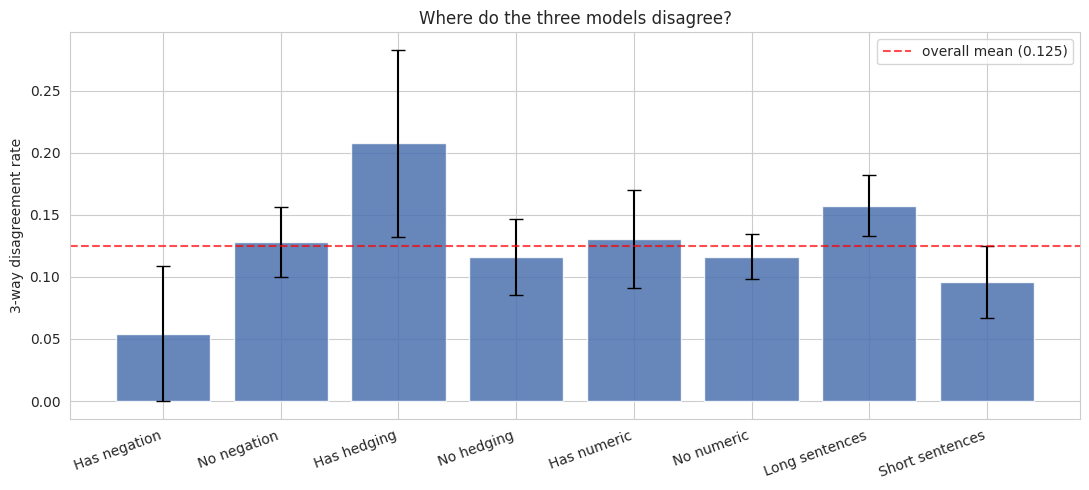

In [ ]:
# Visualize: disagreement by segment (just the means for clarity)
fig, ax = plt.subplots(figsize=(11, 5))
seg_means = []
seg_stds = []
seg_names = []
for name, fn in segment_definitions:
    if name == "ALL":
        continue
    per_seed = []
    for r in all_results:
        mask = fn(r.test_df)
        if mask.sum() == 0:
            continue
        seg_preds = {m: r.preds[m][mask.values] for m in ["TextCNN", "BiLSTM", "FinBERT"]}
        per_seed.append(three_way_disagreement(seg_preds))
    seg_names.append(name)
    seg_means.append(np.mean(per_seed))
    seg_stds.append(np.std(per_seed, ddof=1) if len(per_seed) > 1 else 0)

# Reference: ALL segment
all_per_seed = [three_way_disagreement(r.preds) for r in all_results]
all_mean = np.mean(all_per_seed)

x = np.arange(len(seg_names))
ax.bar(x, seg_means, yerr=seg_stds, capsize=5, alpha=0.85, color="#4C72B0")
ax.axhline(all_mean, color="red", linestyle="--", alpha=0.7, label=f"overall mean ({all_mean:.3f})")
ax.set_xticks(x)
ax.set_xticklabels(seg_names, rotation=20, ha="right")
ax.set_ylabel("3-way disagreement rate")
ax.set_title("Where do the three models disagree?")
ax.legend()
plt.tight_layout()
plt.show()

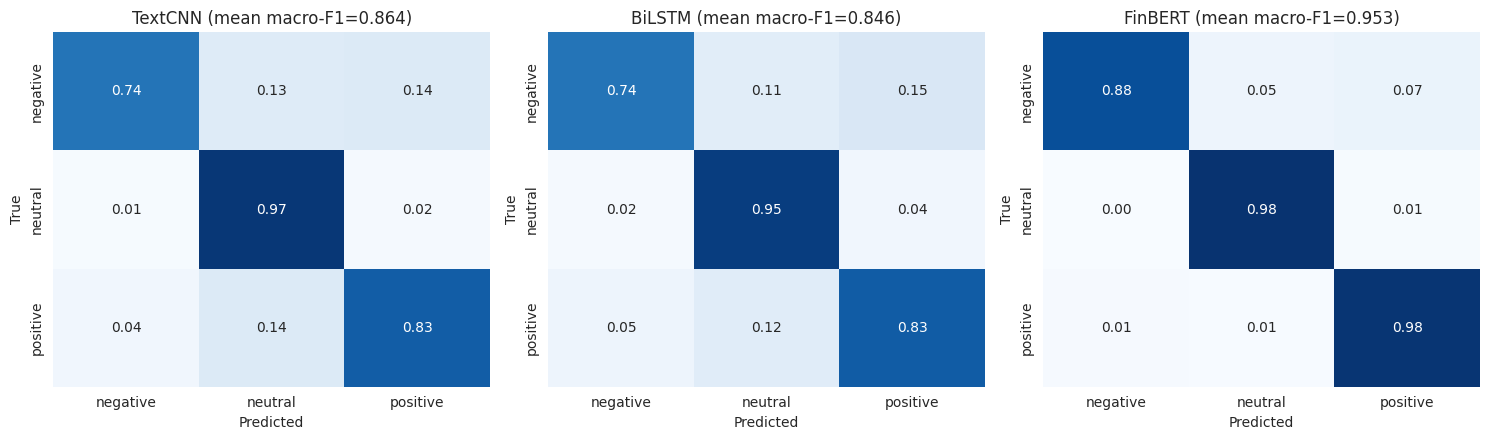

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, m in zip(axes, ["TextCNN", "BiLSTM", "FinBERT"]):
    # Sum confusion matrices across seeds
    cm_total = np.zeros((3, 3), dtype=int)
    for r in all_results:
        cm_total += confusion_matrix(r.test_df["true"], r.preds[m], labels=[0, 1, 2])
    cm_norm = cm_total / cm_total.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
                ax=ax, cbar=False, vmin=0, vmax=1)
    mean_f1 = np.mean([r.metrics[m]["macro_f1"] for r in all_results])
    ax.set_title(f"{m} (mean macro-F1={mean_f1:.3f})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
plt.show()

### 17. Qualitative inspection
The disagreement statistics become more tangible when viewed through the underlying sentences. These examples are complete three-way disagreements, where TextCNN, BiLSTM, and FinBERT each assign a different label to the same text.
Such cases are uncommon; most of the overall 13.5% disagreement rate comes from two-versus-one splits rather than complete three-way divergence. Nevertheless, these examples illustrate the kinds of sentences on which architectures differ most: language that is qualified, context-dependent, or contains competing sentiment signals. They are also exactly the type of cases a human reviewer would examine during model validation.

In [ ]:
r0 = all_results[0]
disagree_mask = (
    (r0.preds["TextCNN"] != r0.preds["BiLSTM"]) &
    (r0.preds["BiLSTM"] != r0.preds["FinBERT"]) &
    (r0.preds["TextCNN"] != r0.preds["FinBERT"])
)
disagree_examples = r0.test_df.loc[disagree_mask, ["text", "true"]].copy()
disagree_examples["true_label"] = disagree_examples["true"].map({0: "negative", 1: "neutral", 2: "positive"})
disagree_examples["TextCNN"] = [LABEL_NAMES[p] for p in r0.preds["TextCNN"][disagree_mask]]
disagree_examples["BiLSTM"] = [LABEL_NAMES[p] for p in r0.preds["BiLSTM"][disagree_mask]]
disagree_examples["FinBERT"] = [LABEL_NAMES[p] for p in r0.preds["FinBERT"][disagree_mask]]

print(f"Found {len(disagree_examples)} examples of complete three-way disagreement (seed {r0.seed}).")
print("First 10:")
disagree_examples[["text", "true_label", "TextCNN", "BiLSTM", "FinBERT"]].head(10)

Found 3 examples of complete three-way disagreement (seed 42).
First 10:


,text,true_label,TextCNN,BiLSTM,FinBERT
244,`` These developments partly reflect the gover...,neutral,neutral,negative,positive
307,Relations with the City have been further dama...,negative,positive,negative,neutral
325,According to CEO Matti Perkonoja of the parent...,negative,neutral,positive,negative


In [ ]:
# 2-vs-1 disagreements: two models agree, one dissents (the bulk of the 13.5%)
r0 = all_results[0]
tc, bl, fb = r0.preds["TextCNN"], r0.preds["BiLSTM"], r0.preds["FinBERT"]

# any disagreement (not unanimous), then exclude the full three-way splits
not_unanimous = ~((tc == bl) & (bl == fb))
all_three_diff = (tc != bl) & (bl != fb) & (tc != fb)
two_v_one = not_unanimous & ~all_three_diff

ex = r0.test_df.loc[two_v_one, ["text", "true"]].copy()
ex["true_label"] = ex["true"].map({0: "negative", 1: "neutral", 2: "positive"})
ex["TextCNN"] = [LABEL_NAMES[p] for p in tc[two_v_one]]
ex["BiLSTM"]  = [LABEL_NAMES[p] for p in bl[two_v_one]]
ex["FinBERT"] = [LABEL_NAMES[p] for p in fb[two_v_one]]

# tag which model is the lone dissenter, and whether the majority was right
import pandas as pd
def dissenter(row):
    labs = {"TextCNN": row["TextCNN"], "BiLSTM": row["BiLSTM"], "FinBERT": row["FinBERT"]}
    vals = list(labs.values())
    for m, v in labs.items():
        if vals.count(v) == 1:
            return m
    return ""
ex["dissenter"] = ex.apply(dissenter, axis=1)

print(f"Found {len(ex)} two-vs-one disagreements in seed {r0.seed} "
      f"(out of {len(r0.test_df)} test sentences).")
pd.set_option("display.max_colwidth", 120)
print(ex[["text","true_label","TextCNN","BiLSTM","FinBERT","dissenter"]].head(15).to_string(index=False))

Found 30 two-vs-one disagreements in seed 42 (out of 339 test sentences).
                                                                                                                                                                                                                                                    text true_label  TextCNN   BiLSTM  FinBERT dissenter
                                               These financing arrangements will enable the company to ensure , in line with its treasury policy , that it has sufficient financial instruments at its disposal for its potential capital requirements .   positive  neutral  neutral positive   FinBERT
                                                                                                             Cash flow from operations in January-December 2008 was a negative EUR 18.1 mn compared to EUR 39.0 mn in the corresponding period in 2007 .   negative positive positive negative   FinBERT
                                   

In [ ]:
import pickle
with open("all_results_seed42_preds.pkl", "wb") as f:
    pickle.dump({
        "text": all_results[0].test_df["text"].tolist(),
        "true": all_results[0].test_df["true"].tolist(),
        "TextCNN": all_results[0].preds["TextCNN"].tolist(),
        "BiLSTM": all_results[0].preds["BiLSTM"].tolist(),
        "FinBERT": all_results[0].preds["FinBERT"].tolist(),
    }, f)

print(f"Saved seed-{all_results[0].seed} predictions: {len(all_results[0].test_df)} sentences")
print("File: all_results_seed42_preds.pkl")

Saved seed-42 predictions: 339 sentences
File: all_results_seed42_preds.pkl


Yes — use **`fin.ipynb` as final**.

I checked the notebook structure. Your main cleanup before GitHub is:

1. **Remove duplicated markdown headings**

   * Section 6 duplicated
   * Section 8 duplicated
   * Section 9 duplicated
   * Section 11 duplicated
   * Section 12 duplicated
   * Section 13 duplicated
   * “Where the models disagree” duplicated
   * “Qualitative inspection” duplicated

2. **Move `pip install` above imports**

   * Right now imports appear before install. For GitHub/Colab readability, install cell should come first.

3. **Rename notebook before upload**
   Use:
   `FinNLP_SentimentRisk_Classifier.ipynb`

4. **Keep this repo name**
   `finnlp-sentiment-risk-classifier`

5. **Your README should frame it as**

   > Financial NLP sentiment classification benchmark comparing TextCNN, BiLSTM, and FinBERT with model-risk diagnostics: calibration, disagreement, and segment-level analysis.

This is a strong GitHub project. Do the cleanup, then publish. Your standard stays intact.


https://chatgpt.com/c/69ed6f43-c8b4-83ea-ab27-ecf6842117b6